In [35]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.io import loadmat
import scipy.optimize
from time import time
import tensorflow_probability as tfp

print ( tf.config.list_physical_devices ( 'GPU' ) )
tf.keras.backend.set_floatx ( 'float64' )
print ( "Libraries imported" )

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Libraries imported


In [36]:
adam_epochs = 50000
lbfgs_maxiter = 50000

In [37]:
cylinder_wake = loadmat ( "cylinder_nektar_wake.mat" )
print ( cylinder_wake.keys() )

X_star = cylinder_wake['X_star']
t = cylinder_wake['t']
U_star = cylinder_wake['U_star']
p_star = cylinder_wake['p_star']

print ( X_star.shape, t.shape, U_star.shape, p_star.shape )

dict_keys(['__header__', '__version__', '__globals__', 'X_star', 't', 'U_star', 'p_star'])
(5000, 2) (200, 1) (5000, 2, 200) (5000, 200)


In [38]:
N = 5000

x = X_star[:, 0:1]
y = X_star[:, 1:2]

x_repeat = np.tile ( x, ( 1, t.shape[0] ) )
y_repeat = np.tile ( y, ( 1, t.shape[0] ) )
t_repeat = np.tile ( t.T, ( x.shape[0], 1 ) )

X_T = np.hstack ( [ x_repeat.reshape ( -1, 1 ), y_repeat.reshape ( -1, 1 ), t_repeat.reshape ( -1, 1 ) ] )

u = U_star[:, 0, :].reshape ( -1, 1 )
v = U_star[:, 1, :].reshape ( -1, 1 )
p = p_star.reshape ( -1, 1 )

rows = X_T.shape[0]

rng = np.random.default_rng()
indices = rng.choice ( np.arange ( 0, rows ), size = N, replace = False )

# For data loss

x_train = X_T[indices]
y_train = np.hstack ( [ u[indices], v[indices] ] )
y_train = tf.cast ( y_train, tf.float64 )

# For collocation point loss

x_tf = tf.convert_to_tensor ( x_train[:, 0:1], dtype = tf.float64 )
y_tf = tf.convert_to_tensor ( x_train[:, 1:2], dtype = tf.float64 )
t_tf = tf.convert_to_tensor ( x_train[:, 2:3], dtype = tf.float64 )

print ( x_train.shape, y_train.shape )
print ( x_tf.shape, y_tf.shape, t_tf.shape )

(5000, 3) (5000, 2)
(5000, 1) (5000, 1) (5000, 1)


In [39]:
lambda_1 = tf.Variable ( 0.0, dtype = tf.float64, name = "lambda_1" )
lambda_2 = tf.Variable ( 0.0, dtype = tf.float64, name = "lambda_2" )

In [40]:
model = tf.keras.Sequential ( [
        tf.keras.layers.InputLayer ( input_shape = ( 3, ) ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 3 )
    ] )

print ( model.summary() )

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,503 (636.74 KB)

 Trainable params: 81,503 (636.74 KB)

 Non-trainable params: 0 (0.00 B)

None


In [41]:

@tf.function
def MSE_b():
    pred = model ( tf.concat ( [ x_tf, y_tf, t_tf ], axis = 1 ) )
    u_pred = pred[:, 0:1]
    v_pred = pred[:, 1:2]

    vel_pred = tf.keras.ops.hstack ( [ u_pred, v_pred ] )
    vel_pred = tf.cast ( vel_pred, tf.float64 )

    return tf.reduce_mean ( tf.square ( vel_pred - y_train ) )

@tf.function
def MSE_f():
    with tf.GradientTape ( persistent = True ) as tape2:
        tape2.watch ( [ x_tf, y_tf, t_tf ] )
        with tf.GradientTape ( persistent = True ) as tape1:
            tape1.watch ( [ x_tf, y_tf, t_tf ] )

            pred = model ( tf.concat ( [ x_tf, y_tf, t_tf ], axis = 1 ) )
            pred = tf.cast ( pred, tf.float64 )

            u_pred = pred[:, 0:1]
            v_pred = pred[:, 1:2]
            p_pred = pred[:, 2:3]

        p_x = tape1.gradient ( p_pred, x_tf )
        p_y = tape1.gradient ( p_pred, y_tf )

        u_t = tape1.gradient ( u_pred, t_tf )
        v_t = tape1.gradient ( v_pred, t_tf )
        u_x = tape1.gradient ( u_pred, x_tf )
        v_x = tape1.gradient ( v_pred, x_tf )
        u_y = tape1.gradient ( u_pred, y_tf )
        v_y = tape1.gradient ( v_pred, y_tf )

    u_xx = tape2.gradient ( u_x, x_tf )
    v_xx = tape2.gradient ( v_x, x_tf )
    u_yy = tape2.gradient ( u_y, y_tf )
    v_yy = tape2.gradient ( v_y, y_tf )

    f = u_t + lambda_1 * ( u_pred * u_x + v_pred * u_y ) + p_x - lambda_2 * ( u_xx + u_yy )
    g = v_t + lambda_1 * ( u_pred * v_x + v_pred * v_y ) + p_y - lambda_2 * ( v_xx + v_yy )
    
    del tape1, tape2
    return tf.reduce_mean ( tf.square ( f ) + tf.square ( g ) )

# Extra continuity loss since psi is removed!

@tf.function
def MSE_c():
    with tf.GradientTape ( persistent = True ) as tape:
        tape.watch ( [ x_tf, y_tf, t_tf ] )

        pred = model ( tf.concat ( [ x_tf, y_tf, t_tf ], axis = 1 ) )
        u_pred = pred[:, 0:1]
        v_pred = pred[:, 1:2]

    u_x = tape.gradient ( u_pred, x_tf )
    v_y = tape.gradient ( v_pred, y_tf )

    del tape
    return tf.reduce_mean ( tf.square ( u_x + v_y ) )
    
print ( MSE_b(), MSE_f(), MSE_c() )

tf.Tensor(0.5428573365981137, shape=(), dtype=float64) tf.Tensor(0.008471194588905311, shape=(), dtype=float64) tf.Tensor(0.0019127660023208293, shape=(), dtype=float64)


In [42]:

opt = tf.keras.optimizers.AdamW ( learning_rate = 1e-3, weight_decay = 0.0 )

print ( "INFO: Training Started" )
start = time()

for epoch in range ( 1, adam_epochs + 1 ):
    with tf.GradientTape() as tape:
        loss_b = MSE_b()
        loss_f = MSE_f()
        loss_c = MSE_c()
        loss = loss_b + loss_f + loss_c

    all_trainable_vars = model.trainable_variables + [ lambda_1, lambda_2 ]

    grads = tape.gradient ( loss, all_trainable_vars )
    opt.apply_gradients ( zip ( grads, all_trainable_vars ) )
    
    if ( epoch % 1000 == 0 ):
        print ( "INFO: Adam Epoch {} reached; Time elapsed: {}\nlambda_1: {}; lambda_2: {}\nMSE_b : {}, MSE_f: {}, MSE_c: {}\n".format ( str ( epoch ), str ( time() - start ), str ( lambda_1.numpy() ), str ( lambda_2.numpy() ), str ( float ( loss_b ) ), str ( float ( loss_f ) ), str ( float ( loss_c ) ) ) )

    if ( epoch == 15000 ):
        print ( "INFO: Adam Learning rate now 0.0001 and decay 0.0001" )
        opt.learning_rate.assign ( 1e-4 )
        opt.weight_decay = 1e-4

    if ( epoch == 30000 ):
        print ( "INFO: Adam Learning rate now 1e-5" )
        opt.learning_rate.assign ( 1e-5 )
        opt.weight_decay = 1e-4

    if ( epoch == 50000 ):
        print ( "INFO: Adam Learning rate now 1e-6" )
        opt.learning_rate.assign ( 1e-6 )
        opt.weight_decay = 1e-4

print ( "INFO: Training with Adam done" )


INFO: Training Started
INFO: Adam Epoch 1000 reached; Time elapsed: 184.89296412467957
lambda_1: 0.8646802816999846; lambda_2: 0.02116956048536399
MSE_b : 0.02989335804501848, MSE_f: 0.0012441330199158384, MSE_c: 0.0003850475937579488

INFO: Adam Epoch 2000 reached; Time elapsed: 369.1858260631561
lambda_1: 0.9679713986694763; lambda_2: 0.015909996668207457
MSE_b : 0.0021239550154060582, MSE_f: 0.0007380602993458788, MSE_c: 0.00020820179163875342

INFO: Adam Epoch 3000 reached; Time elapsed: 553.4748373031616
lambda_1: 0.9827149080202113; lambda_2: 0.013475533145749693
MSE_b : 0.0008712035973586829, MSE_f: 0.00039459654601478784, MSE_c: 0.00011526820243577494

INFO: Adam Epoch 4000 reached; Time elapsed: 737.8578815460205
lambda_1: 0.9888231231504332; lambda_2: 0.01247898605995402
MSE_b : 0.000383229251892302, MSE_f: 0.00025696752347469006, MSE_c: 6.462790384015665e-05

INFO: Adam Epoch 5000 reached; Time elapsed: 922.5703365802765
lambda_1: 0.9924789426304343; lambda_2: 0.012101827571

In [43]:
import scipy.optimize
import numpy as np

start_lbfgs = time()

print ( "INFO: L-BFGS Training Started" )
all_trainable_vars = model.trainable_variables + [lambda_1, lambda_2]

def pack_weights ( vars ):
    return tf.concat ( [ tf.reshape ( v, [-1] ) for v in vars ], axis = 0 )

def unpack_weights ( vars, flat ):
    idx = 0
    for v in vars:
        size = tf.size ( v )
        shape = v.shape
        v.assign ( tf.reshape ( flat[idx:idx+size], shape ) )
        idx += size

def scipy_loss_and_grad ( flat_weights_numpy ):
    flat_weights_tf = tf.convert_to_tensor ( flat_weights_numpy, dtype = tf.float64 )
    unpack_weights ( all_trainable_vars, flat_weights_tf )
    
    with tf.GradientTape() as tape:
        loss = MSE_b() + MSE_f() + MSE_c()
        
    grads = tape.gradient ( loss, all_trainable_vars )
    flat_grads_tf = pack_weights ( grads )
    
    loss_np = loss.numpy().astype ( np.float64 )
    grads_np = flat_grads_tf.numpy().astype ( np.float64 )
    
    return loss_np, grads_np

initial_flat_weights = pack_weights ( all_trainable_vars ).numpy().astype ( np.float64 )

results = scipy.optimize.minimize (
    fun = scipy_loss_and_grad,
    x0 = initial_flat_weights,
    method = 'L-BFGS-B',
    jac = True,
    options = {
        'maxiter': lbfgs_maxiter,
        'ftol': 1e-12,
        'gtol': 1e-12,
        'disp': True
    } )

final_optimal_weights = tf.convert_to_tensor ( results.x, dtype = tf.float64 )
unpack_weights ( all_trainable_vars, final_optimal_weights )

print ( "INFO: L-BFGS Training done; Time elapsed: {}".format ( str ( time() - start_lbfgs ) ) )
print ( "INFO: lambda_1 : {}, lambda_2: {}".format ( str ( float ( lambda_1.numpy() ) ), str ( float ( lambda_2.numpy() ) ) ) )
print ( "INFO: Final loss values - MSE_b : {}, MSE_f: {}, MSE_c: {}".format ( str ( float ( MSE_b() ) ), str ( float ( MSE_f() ) ), str ( float ( MSE_c() ) ) ) )
print ( "INFO: Total L-BFGS Iterations: {}".format ( results.nit ) )

INFO: L-BFGS Training Started
INFO: L-BFGS Training done; Time elapsed: 3712.2610232830048
INFO: lambda_1 : 1.000225640796271, lambda_2: 0.010077925043920315
INFO: Final loss values - MSE_b : 9.927599497366209e-07, MSE_f: 4.6787333135837025e-07, MSE_c: 2.0067721617804324e-07
INFO: Total L-BFGS Iterations: 14057


In [44]:
# Velocity L2 relative error calculation

vel_soln = np.hstack ( [ u, v ] )

x_all = tf.convert_to_tensor ( x_repeat.flatten().reshape ( -1, 1 ), dtype = tf.float64 )
y_all = tf.convert_to_tensor ( y_repeat.flatten().reshape ( -1, 1 ), dtype = tf.float64 )
t_all = tf.convert_to_tensor ( t_repeat.flatten().reshape ( -1, 1 ), dtype = tf.float64 )

model_pred = model ( tf.concat ( [ x_all, y_all, t_all ], axis = 1 )  )
u_pred = model_pred[:, 0:1]
v_pred = model_pred[:, 1:2]

vel_pred = np.hstack ( [ u_pred, v_pred ] )

print ( x_all.shape, y_all.shape, t_all.shape, vel_soln.shape, model_pred.shape )

vel_error = np.linalg.norm ( vel_pred - vel_soln ) / np.linalg.norm ( vel_soln )

print ( "\nVelocity relative L2 Error:", vel_error )

(1000000, 1) (1000000, 1) (1000000, 1) (1000000, 2) (1000000, 3)

Velocity relative L2 Error: 0.0035165869470527075


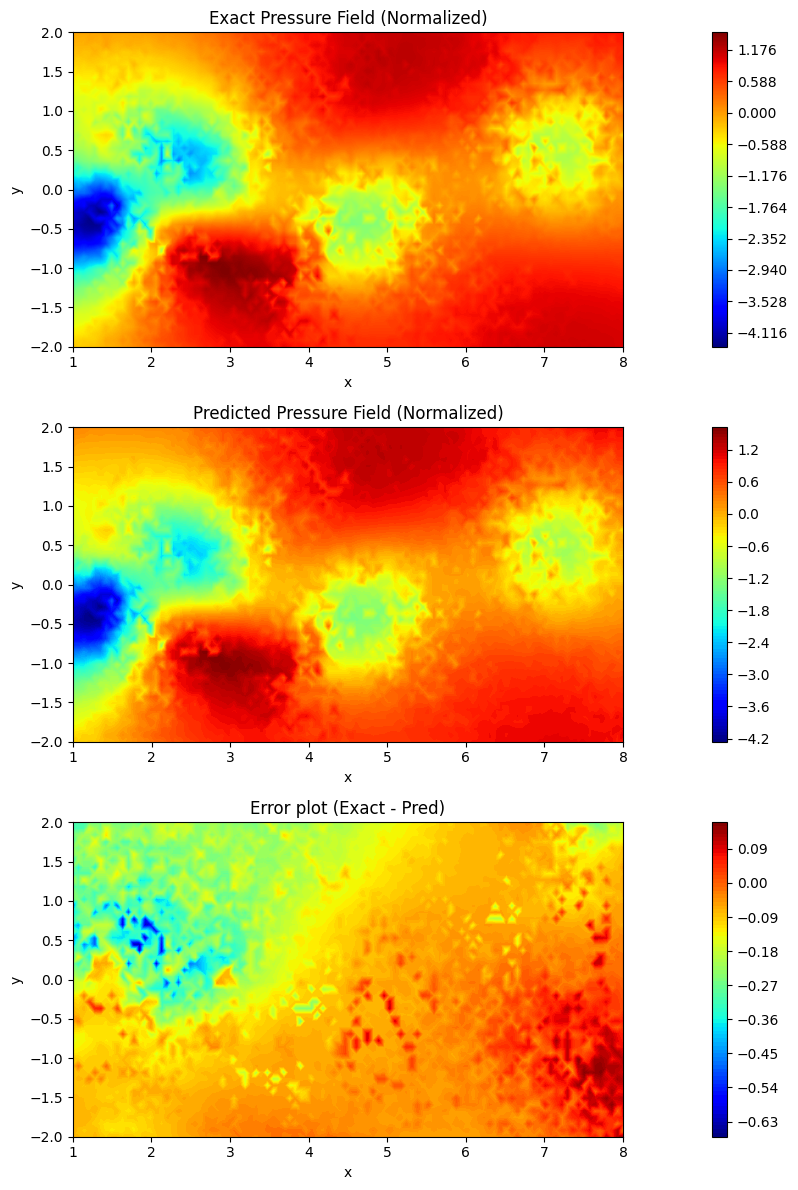

0.6089495361212589 0.6303022630955852


In [45]:

pressure_exact = p_star.flatten()
pressure_pred = model_pred[:, 2:3].numpy().reshape ( pressure_exact.shape )

mean_exact = np.mean ( pressure_exact )
std_exact = np.std ( pressure_exact )

mean_pred = np.mean ( pressure_pred )
std_pred = np.std ( pressure_pred )

p_exact_norm = ( pressure_exact - mean_exact ) / std_exact
p_pred_norm = ( pressure_pred - mean_pred ) / std_pred

fig, ax = plt.subplots ( 3, 1, figsize = ( 18, 12 ) )

contour_exact = ax[0].tricontourf ( x_repeat.flatten(), y_repeat.flatten(), p_exact_norm, levels = 1000, cmap = 'jet' )
fig.colorbar ( contour_exact, ax = ax[0] )
ax[0].set_title ( 'Exact Pressure Field (Normalized)' )
ax[0].set_xlabel ( 'x' )
ax[0].set_ylabel ( 'y' )
ax[0].set_aspect ( 'equal' )

contour_pred = ax[1].tricontourf ( x_repeat.flatten(), y_repeat.flatten(), p_pred_norm, levels = 100, cmap = 'jet' )
fig.colorbar ( contour_pred, ax = ax[1] )
ax[1].set_title ( 'Predicted Pressure Field (Normalized)' )
ax[1].set_xlabel ( 'x' )
ax[1].set_ylabel ( 'y' )
ax[1].set_aspect ( 'equal' )

contour_diff = ax[2].tricontourf ( x_repeat.flatten(), y_repeat.flatten(), p_exact_norm - p_pred_norm, levels = 100, cmap = 'jet' )
fig.colorbar ( contour_diff, ax = ax[2] )
ax[2].set_title ( 'Error plot (Exact - Pred)' )
ax[2].set_xlabel ( 'x' )
ax[2].set_ylabel ( 'y' )
ax[2].set_aspect ( 'equal' )

plt.tight_layout()
plt.show()

print ( pressure_exact.max() - pressure_exact.min(), pressure_pred.max() - pressure_pred.min() )

In [46]:
print ( "Exact lambda values:\nlambda_1: 1, lambda_2: 0.01" )
print ( "\nFinal predicted lambda values:\nlambda_1: {}, lambda_2: {}".format ( lambda_1.numpy(), lambda_2.numpy() ) )

Exact lambda values:
lambda_1: 1, lambda_2: 0.01

Final predicted lambda values:
lambda_1: 1.000225640796271, lambda_2: 0.010077925043920315


In [47]:
model.save_weights ( "latest.weights.h5" )